In [1]:
import numpy as np
import struct
import time
import matplotlib.pyplot as plt

In [2]:
class MnistDataloader:

    def __init__(self, train_img, train_lbl, test_img, test_lbl):
        self.train_img = train_img
        self.train_lbl = train_lbl
        self.test_img = test_img
        self.test_lbl = test_lbl

    def read_data(self, images_path, labels_path):

        with open(labels_path, 'rb') as lbpath:
            magic, n = struct.unpack(">II", lbpath.read(8))
            labels = np.frombuffer(lbpath.read(), dtype=np.uint8)

        with open(images_path, 'rb') as imgpath:
            magic, num, rows, cols = struct.unpack(">IIII", imgpath.read(16))
            images = np.frombuffer(imgpath.read(), dtype=np.uint8)
            images = images.reshape(len(labels), 28, 28)

        return images / 255.0, labels  # normalized once here

    def load(self):
        x_train, y_train = self.read_data(self.train_img, self.train_lbl)
        x_test, y_test = self.read_data(self.test_img, self.test_lbl)
        return (x_train, y_train), (x_test, y_test)

In [3]:
# FIX 1: train files first, test files second (were swapped before)
loader = MnistDataloader(
    "/kaggle/input/datasets/nithekaa/deeplearnig/train-images.idx3-ubyte",
    "/kaggle/input/datasets/nithekaa/deeplearnig/train-labels.idx1-ubyte",
    "/kaggle/input/datasets/nithekaa/deeplearnig/t10k-images.idx3-ubyte",
    "/kaggle/input/datasets/nithekaa/deeplearnig/t10k-labels.idx1-ubyte"
)

(x_train, y_train), (x_test, y_test) = loader.load()

# FIX 2: removed x_train/x_test / 255.0 — already done inside read_data()
print("x_train range:", x_train.min(), "-", x_train.max())  # should be 0.0 - 1.0
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)

x_train range: 0.0 - 1.0
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [4]:
x_train_small = x_train[:2000]
y_train_small = y_train[:2000]

x_val = x_train[2000:3000]
y_val = y_train[2000:3000]

x_test_small = x_test[:1000]
y_test_small = y_test[:1000]

In [5]:
def relu(x):
    return np.maximum(0, x)

def relu_backward(x, grad):
    return grad * (x > 0)

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

In [6]:
def cross_entropy(probs, labels):
    onehot = np.eye(10)[labels]
    return -np.mean(np.sum(onehot * np.log(probs + 1e-9), axis=1))

def accuracy(preds, labels):
    pred = np.argmax(preds, axis=1)
    return np.mean(pred == labels)

def kl_divergence(probs, labels):
    onehot = np.eye(10)[labels]
    return np.mean(
        np.sum(onehot * np.log((onehot + 1e-9) / (probs + 1e-9)), axis=1)
    )

In [7]:
def conv_complexity(input_size, kernel, stride, filters):
    out = (input_size - kernel) // stride + 1
    return out * out * kernel * kernel * filters

In [8]:
class Conv2D:

    def __init__(self, filters=8, kernel=3, stride=1, lr=0.01):  # FIX 4: lr 0.001 -> 0.01
        self.filters = filters
        self.kernel = kernel
        self.stride = stride
        self.lr = lr
        self.kernels = np.random.randn(filters, kernel, kernel) * 0.1
        self.bias = np.zeros(filters)

    def forward(self, x):
        self.x = x
        b, h, w = x.shape
        out_h = (h - self.kernel) // self.stride + 1
        out_w = (w - self.kernel) // self.stride + 1
        out = np.zeros((b, self.filters, out_h, out_w))

        for i in range(b):
            for f in range(self.filters):
                for y in range(out_h):
                    for z in range(out_w):
                        region = x[i,
                            y*self.stride:y*self.stride+self.kernel,
                            z*self.stride:z*self.stride+self.kernel]
                        out[i, f, y, z] = np.sum(region * self.kernels[f]) + self.bias[f]
        return out

    def backward(self, grad_out):
        b, _, out_h, out_w = grad_out.shape
        grad_x = np.zeros_like(self.x)
        grad_k = np.zeros_like(self.kernels)
        grad_b = np.zeros_like(self.bias)

        for i in range(b):
            for f in range(self.filters):
                for y in range(out_h):
                    for z in range(out_w):
                        region = self.x[i,
                            y*self.stride:y*self.stride+self.kernel,
                            z*self.stride:z*self.stride+self.kernel]
                        grad_k[f] += grad_out[i, f, y, z] * region
                        grad_x[i,
                            y*self.stride:y*self.stride+self.kernel,
                            z*self.stride:z*self.stride+self.kernel] += \
                            grad_out[i, f, y, z] * self.kernels[f]
                grad_b[f] += np.sum(grad_out[i, f])

        self.kernels -= self.lr * grad_k
        self.bias -= self.lr * grad_b
        return grad_x

In [9]:
class MaxPool:

    def __init__(self, size=2):
        self.size = size

    def forward(self, x):
        self.x = x
        b, c, h, w = x.shape
        self.out_h = h // self.size
        self.out_w = w // self.size
        out = np.zeros((b, c, self.out_h, self.out_w))

        for i in range(b):
            for j in range(c):
                for y in range(self.out_h):
                    for z in range(self.out_w):
                        region = x[i, j,
                            y*self.size:(y+1)*self.size,
                            z*self.size:(z+1)*self.size]
                        out[i, j, y, z] = np.max(region)
        return out

    def backward(self, grad_out):
        b, c, _, _ = grad_out.shape
        grad_x = np.zeros_like(self.x)

        for i in range(b):
            for j in range(c):
                for y in range(self.out_h):
                    for z in range(self.out_w):
                        region = self.x[i, j,
                            y*self.size:(y+1)*self.size,
                            z*self.size:(z+1)*self.size]
                        max_val = np.max(region)
                        for m in range(self.size):
                            for n in range(self.size):
                                if region[m, n] == max_val:
                                    grad_x[i, j,
                                        y*self.size+m,
                                        z*self.size+n] += grad_out[i, j, y, z]
        return grad_x

In [10]:
class Dense:

    def __init__(self, inp, out, lr=0.01):  # FIX 4: lr 0.001 -> 0.01
        self.lr = lr
        self.w = np.random.randn(inp, out) * 0.1
        self.b = np.zeros(out)

    def forward(self, x):
        self.x = x
        return np.dot(x, self.w) + self.b

    def backward(self, grad):
        grad_x = np.dot(grad, self.w.T)
        grad_w = np.dot(self.x.T, grad)
        grad_b = np.sum(grad, axis=0)
        self.w -= self.lr * grad_w
        self.b -= self.lr * grad_b
        return grad_x

In [11]:
kernel_sizes = [3, 5, 7]
strides = [1, 2, 3]
epochs = 10
batch = 32
results = []

for kernel in kernel_sizes:
    for stride in strides:

        conv_out_size = (28 - kernel) // stride + 1
        pool_out_size = conv_out_size // 2

        # Skip invalid configs where pool output is 0
        if pool_out_size <= 0:
            print(f"Skipping kernel={kernel}, stride={stride} — feature map too small")
            continue

        print(f"\n=== kernel={kernel}, stride={stride} | conv_out={conv_out_size}, pool_out={pool_out_size} ===")
        print(f"    Complexity: {conv_complexity(28, kernel, stride, 8)}")

        # Re-initialize layers fresh for each config
        conv = Conv2D(filters=8, kernel=kernel, stride=stride, lr=0.01)
        pool = MaxPool(2)
        dense1 = Dense(8 * pool_out_size * pool_out_size, 128, lr=0.01)
        dense2 = Dense(128, 10, lr=0.01)

        # Shuffle once before training
        perm = np.random.permutation(len(x_train_small))
        x_tr = x_train_small[perm]
        y_tr = y_train_small[perm]

        total_time = 0

        for e in range(epochs):
            start = time.time()
            loss_total = 0

            for i in range(0, len(x_tr), batch):
                x = x_tr[i:i+batch]
                y = y_tr[i:i+batch]
                b_size = x.shape[0]

                # Forward
                c_out = conv.forward(x)
                r_out = relu(c_out)
                p_out = pool.forward(r_out)
                flat  = p_out.reshape(b_size, -1)
                d1    = dense1.forward(flat)
                r2    = relu(d1)
                logits = dense2.forward(r2)
                probs  = softmax(logits)

                loss = cross_entropy(probs, y)
                loss_total += loss

                # Backward
                onehot = np.eye(10)[y]
                grad = (probs - onehot) / b_size
                grad = dense2.backward(grad)
                grad = relu_backward(r2, grad)
                grad = dense1.backward(grad)
                grad = grad.reshape(b_size, 8, p_out.shape[2], p_out.shape[3])
                grad = pool.backward(grad)
                conv.backward(grad)

            elapsed = time.time() - start
            total_time += elapsed
            print(f"  Epoch {e+1}/{epochs} | Loss: {loss_total:.4f} | Time: {elapsed:.1f}s")

        # Validation accuracy
        all_probs = []
        for i in range(len(x_val)):
            xv = x_val[i:i+1]
            co = conv.forward(xv)
            ro = relu(co)
            po = pool.forward(ro)
            fl = po.reshape(1, -1)
            d1 = dense1.forward(fl)
            r2 = relu(d1)
            lg = dense2.forward(r2)
            all_probs.append(softmax(lg)[0])

        all_probs = np.array(all_probs)
        val_acc = accuracy(all_probs, y_val)
        val_kl  = kl_divergence(all_probs, y_val)

        print(f"  >> Val Accuracy: {val_acc:.4f} | KL: {val_kl:.4f} | Total Time: {total_time:.1f}s")

        results.append({
            "kernel": kernel,
            "stride": stride,
            "val_acc": val_acc,
            "val_kl": val_kl,
            "complexity": conv_complexity(28, kernel, stride, 8),
            "total_time": total_time
        })


=== kernel=3, stride=1 | conv_out=26, pool_out=13 ===
    Complexity: 48672
  Epoch 1/10 | Loss: 141.9701 | Time: 229.9s
  Epoch 2/10 | Loss: 130.6502 | Time: 231.3s
  Epoch 3/10 | Loss: 103.2133 | Time: 231.4s
  Epoch 4/10 | Loss: 68.9331 | Time: 230.4s
  Epoch 5/10 | Loss: 50.1220 | Time: 230.2s
  Epoch 6/10 | Loss: 40.9685 | Time: 229.8s
  Epoch 7/10 | Loss: 35.6356 | Time: 231.7s
  Epoch 8/10 | Loss: 32.0621 | Time: 231.1s
  Epoch 9/10 | Loss: 29.4573 | Time: 232.0s
  Epoch 10/10 | Loss: 27.4601 | Time: 232.1s
  >> Val Accuracy: 0.8710 | KL: 0.4269 | Total Time: 2309.8s

=== kernel=3, stride=2 | conv_out=13, pool_out=6 ===
    Complexity: 12168
  Epoch 1/10 | Loss: 144.4317 | Time: 59.5s
  Epoch 2/10 | Loss: 142.5273 | Time: 59.5s
  Epoch 3/10 | Loss: 139.6464 | Time: 59.2s
  Epoch 4/10 | Loss: 133.9327 | Time: 59.3s
  Epoch 5/10 | Loss: 122.5757 | Time: 59.2s
  Epoch 6/10 | Loss: 103.8980 | Time: 59.1s
  Epoch 7/10 | Loss: 82.3941 | Time: 59.1s
  Epoch 8/10 | Loss: 65.4549 | Time

In [12]:
print(f"\n{'Kernel':>8} {'Stride':>8} {'Val Acc':>10} {'KL Div':>10} {'Complexity':>12} {'Time(s)':>10}")
print("-" * 65)
for r in results:
    print(f"{r['kernel']:>8} {r['stride']:>8} {r['val_acc']:>10.4f} {r['val_kl']:>10.4f} {r['complexity']:>12} {r['total_time']:>10.1f}")


  Kernel   Stride    Val Acc     KL Div   Complexity    Time(s)
-----------------------------------------------------------------
       3        1     0.8710     0.4269        48672     2309.8
       3        2     0.7980     0.6807        12168      593.5
       3        3     0.5130     1.7458         5832      266.8
       5        1     0.8640     0.4377       115200     1989.1
       5        2     0.8500     0.4870        28800      522.1
       5        3     0.6880     1.0918        12800      222.0
       7        1     0.8930     0.3823       189728     1689.1
       7        2     0.8730     0.4582        47432      420.0
       7        3     0.7310     0.8799        25088      219.1


/tmp/ipykernel_55/466240955.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
/tmp/ipykernel_55/466240955.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)


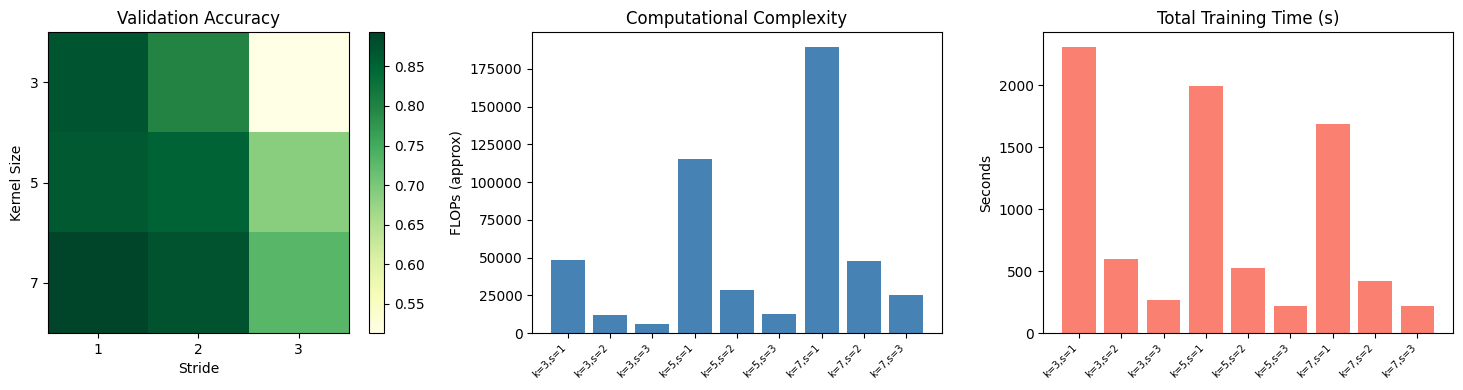

In [13]:
import matplotlib.pyplot as plt

kernels_list = sorted(set(r['kernel'] for r in results))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Accuracy heatmap
acc_matrix = np.zeros((3, 3))
for r in results:
    ki = kernel_sizes.index(r['kernel'])
    si = strides.index(r['stride'])
    acc_matrix[ki, si] = r['val_acc']

im = axes[0].imshow(acc_matrix, cmap='YlGn')
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(strides)
axes[0].set_yticks(range(3)); axes[0].set_yticklabels(kernel_sizes)
axes[0].set_xlabel("Stride"); axes[0].set_ylabel("Kernel Size")
axes[0].set_title("Validation Accuracy")
plt.colorbar(im, ax=axes[0])

# Plot 2: Complexity bar chart
labels = [f"k={r['kernel']},s={r['stride']}" for r in results]
comps  = [r['complexity'] for r in results]
axes[1].bar(labels, comps, color='steelblue')
axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
axes[1].set_title("Computational Complexity")
axes[1].set_ylabel("FLOPs (approx)")

# Plot 3: Training time
times = [r['total_time'] for r in results]
axes[2].bar(labels, times, color='salmon')
axes[2].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
axes[2].set_title("Total Training Time (s)")
axes[2].set_ylabel("Seconds")

plt.tight_layout()
plt.savefig("cnn_experiment_results.png", dpi=150)
plt.show()

/tmp/ipykernel_55/3955965147.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)


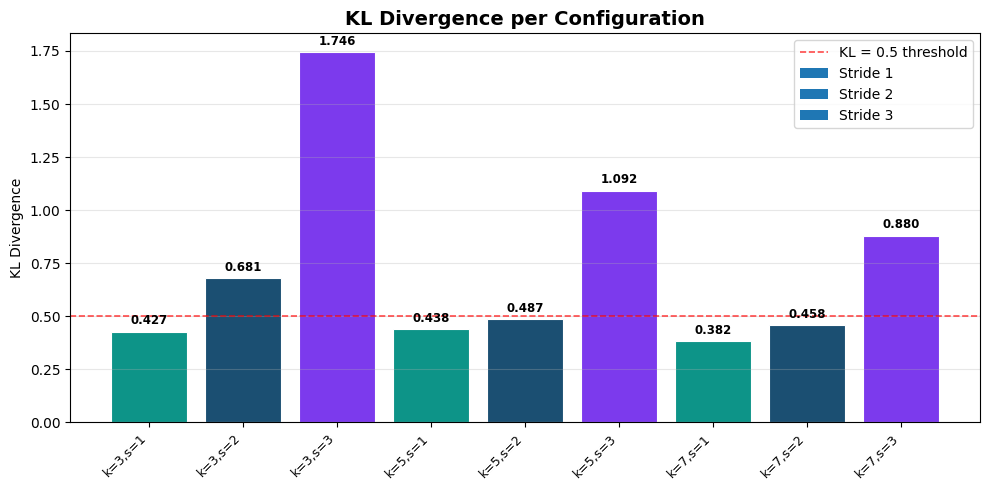

Saved: plot1_kl_bar.png


/tmp/ipykernel_55/3955965147.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)


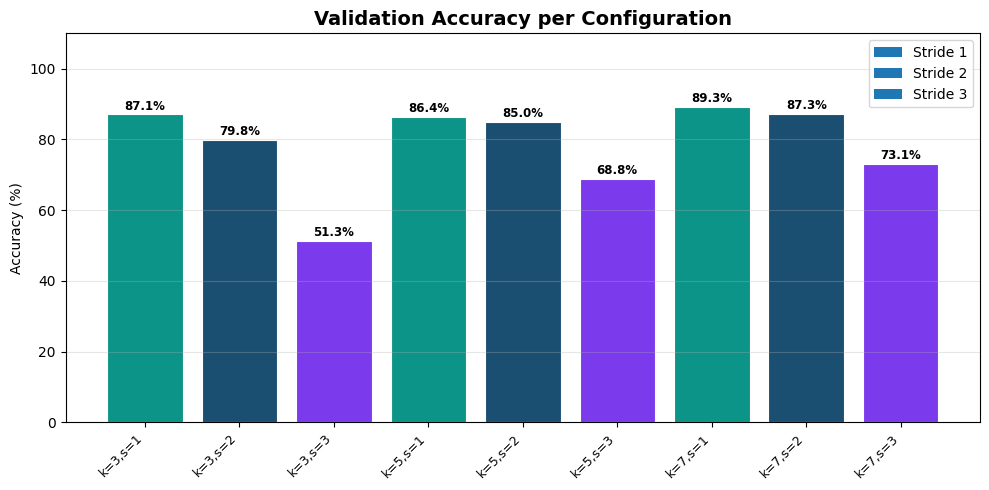

Saved: plot2_accuracy_bar.png


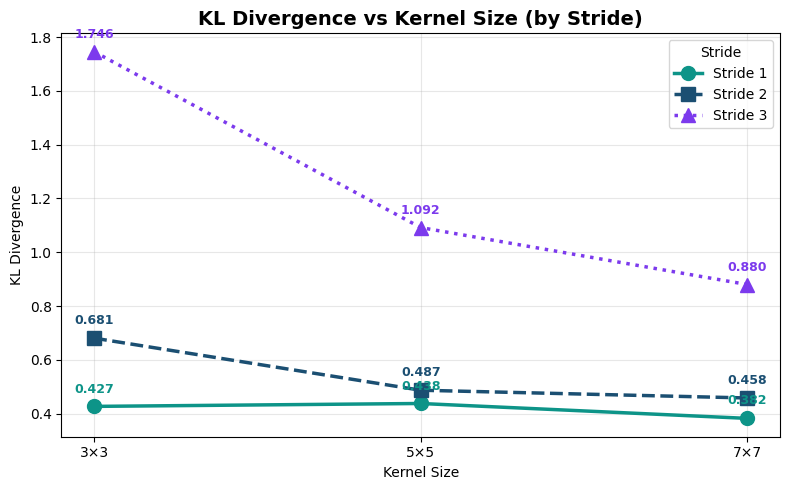

Saved: plot3_kl_curves.png


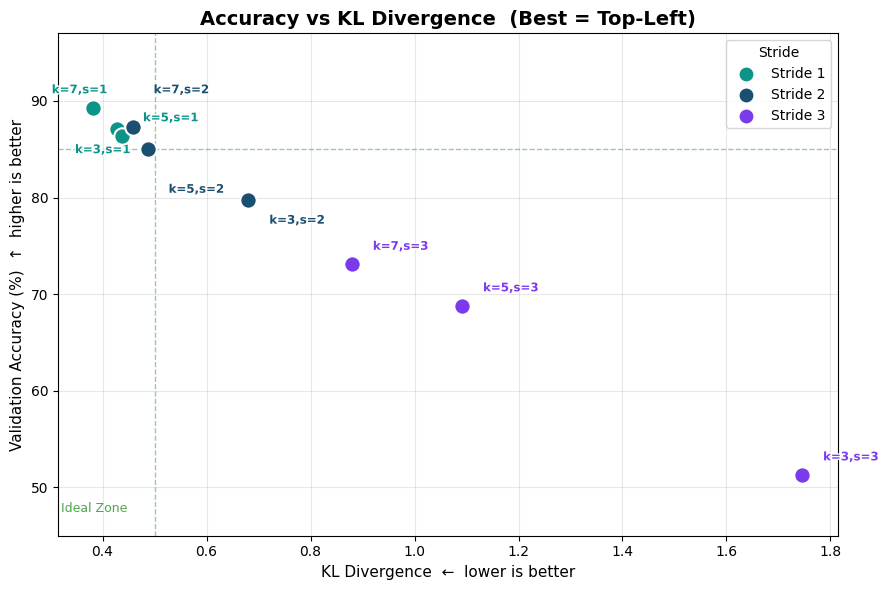

Saved: plot4_scatter.png

✅ All 4 plots saved!
Files: plot1_kl_bar.png, plot2_accuracy_bar.png, plot3_kl_curves.png, plot4_scatter.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

data = [
    (3, 1, 0.8710, 0.4269, 48672,  2309.8),
    (3, 2, 0.7980, 0.6807, 12168,   593.5),
    (3, 3, 0.5130, 1.7458,  5832,   266.8),
    (5, 1, 0.8640, 0.4377, 115200, 1989.1),
    (5, 2, 0.8500, 0.4870, 28800,   522.1),
    (5, 3, 0.6880, 1.0918, 12800,   222.0),
    (7, 1, 0.8930, 0.3823, 189728, 1689.1),
    (7, 2, 0.8730, 0.4582, 47432,   420.0),
    (7, 3, 0.7310, 0.8799, 25088,   219.1),
]

labels       = [f"k={d[0]},s={d[1]}" for d in data]
val_accs     = [d[2] for d in data]
kl_divs      = [d[3] for d in data]
complexities = [d[4] for d in data]
times        = [d[5] for d in data]
strides      = [d[1] for d in data]
kernels      = [d[0] for d in data]

stride_colors = {1: "#0D9488", 2: "#1B4F72", 3: "#7C3AED"}
bar_colors    = [stride_colors[s] for s in strides]
kernel_list   = [3, 5, 7]
stride_styles = {1: ("o-", "#0D9488"), 2: ("s--", "#1B4F72"), 3: ("^:", "#7C3AED")}

# ── PLOT 1: KL Divergence bar chart ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, kl_divs, color=bar_colors, edgecolor="white", linewidth=0.8)
ax.set_title("KL Divergence per Configuration", fontweight="bold", fontsize=14)
ax.set_ylabel("KL Divergence")
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.axhline(y=0.5, color="red", linestyle="--", linewidth=1.2, alpha=0.7, label="KL = 0.5 threshold")
for bar, val in zip(bars, kl_divs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
for s, col in stride_colors.items():
    ax.bar([], [], color=col, label=f"Stride {s}")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot1_kl_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot1_kl_bar.png")

# ── PLOT 2: Validation Accuracy bar chart ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, [v*100 for v in val_accs], color=bar_colors, edgecolor="white", linewidth=0.8)
ax.set_title("Validation Accuracy per Configuration", fontweight="bold", fontsize=14)
ax.set_ylabel("Accuracy (%)")
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, 110)
for bar, val in zip(bars, val_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val*100:.1f}%", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
for s, col in stride_colors.items():
    ax.bar([], [], color=col, label=f"Stride {s}")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot2_accuracy_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot2_accuracy_bar.png")

# ── PLOT 3: KL Divergence curves ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for stride in [1, 2, 3]:
    kl_vals = [d[3] for d in data if d[1] == stride]
    mk, col = stride_styles[stride]
    ax.plot(kernel_list, kl_vals, mk, color=col, linewidth=2.5,
            markersize=10, label=f"Stride {stride}")
    for kx, ky in zip(kernel_list, kl_vals):
        ax.annotate(f"{ky:.3f}", xy=(kx, ky),
                    xytext=(0, 10), textcoords="offset points",
                    fontsize=9, color=col, ha="center", fontweight="bold")
ax.set_title("KL Divergence vs Kernel Size (by Stride)", fontweight="bold", fontsize=14)
ax.set_xlabel("Kernel Size")
ax.set_ylabel("KL Divergence")
ax.set_xticks([3, 5, 7])
ax.set_xticklabels(["3×3", "5×5", "7×7"])
ax.legend(title="Stride", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot3_kl_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot3_kl_curves.png")

# ── PLOT 4: Accuracy vs KL scatter (FIXED labels) ─────────────
fig, ax = plt.subplots(figsize=(9, 6))

# Offset positions to prevent overlapping labels
label_offsets = {
    (7,1): (-0.08,  1.5),   # top-left, push further left+up
    (3,1): (-0.08, -2.5),   # below k=7,s=1
    (5,1): ( 0.04,  1.5),   # right side, up
    (3,2): ( 0.04, -2.5),   # right side, down
    (5,2): ( 0.04, -4.5),   # right side, further down
    (7,2): ( 0.04,  3.5),   # right side, highest
    (3,3): ( 0.04,  1.5),
    (5,3): ( 0.04,  1.5),
    (7,3): ( 0.04,  1.5),
}

for d in data:
    _, s, acc, kl, _, _ = d
    col = stride_colors[s]
    ax.scatter(kl, acc*100, color=col, s=140, zorder=3,
               edgecolors="white", linewidth=1.5)
    ox, oy = label_offsets[(d[0], s)]
    ax.annotate(f"k={d[0]},s={s}", xy=(kl, acc*100),
                xytext=(kl + ox, acc*100 + oy),
                fontsize=8.5, color=col, fontweight="bold",
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])



for s, col in stride_colors.items():
    ax.scatter([], [], color=col, s=80, label=f"Stride {s}")

ax.set_title("Accuracy vs KL Divergence  (Best = Top-Left)", fontweight="bold", fontsize=14)
ax.set_xlabel("KL Divergence  ←  lower is better", fontsize=11)
ax.set_ylabel("Validation Accuracy (%)  ↑  higher is better", fontsize=11)
ax.set_ylim(45, 97)
ax.legend(title="Stride", fontsize=10)
ax.grid(True, alpha=0.3)

# Ideal zone box

ax.axvline(x=0.5, color="green", linestyle="--", alpha=0.4, linewidth=1)
ax.axhline(y=85,  color="green", linestyle="--", alpha=0.4, linewidth=1)
ax.text(0.32, 47.5, "Ideal Zone", fontsize=9, color="green", alpha=0.7)

plt.tight_layout()
plt.savefig("plot4_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot4_scatter.png")

print("\n✅ All 4 plots saved!")
print("Files: plot1_kl_bar.png, plot2_accuracy_bar.png, plot3_kl_curves.png, plot4_scatter.png")